# 24 h test: the run of 2026-10-06 against the two runs before

Same comparison as parts 1 - 4 of `encoder_test.ipynb`, with the new run added. All
three runs go to the **scale** and to the **sample** every 10 min for 24 h, open loop,
at 100000 steps/s, and take a photo at every visit.

| run | encoder | read on | compensation zone | lost-step events |
|---|---|---|---|---|
| `linear 10-03` | linear (magnetic), 1.95 um per count | GPIO 40 / 41 | 5 counts = 9.75 um | 9 |
| `rotational 10-04` | rotational, 0.25 um per count | before the PCNT fix | 39 counts = 9.75 um | 7 |
| `rotational 10-06` | rotational, 0.25 um per count | GPIO 5 / 6 (commit `2e042b0`) | 5 counts = 1.25 um | **0** |

Between 10-04 and 10-06 the encoder pins were changed and the slave was flashed again,
and both places were taught again (x, y, z).

`dx`, `dy` = the shift of a photo against the first photo of its place, in um,
positive = right / down in the photo. Nothing is correlated here: the shifts are read
from `<run>_shift.csv`, so run `24hrstest_shift.py <run>.csv` first. The encoder counts
and the lost-step events come from `<run>.csv`.

1. the shift of the photos, with the lost-step events (6 plots)
2. `dx` of the three runs in one plot, with the compensation zones (2 plots)
3. encoder minus photo: did the encoder see the shift? (2 plots)
4. more: what the compensation saw, where the unseen shift comes from, numbers
5. lost steps: how often, and where the stage stopped

In [1]:
import csv
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# run CSV and um per encoder count of each run. The sign turns the counts into the
# direction of dx (+ = picture to the right): the linear encoder counts up with the
# motor steps, the rotational one counts down (encoder_test.ipynb, part 3).
RUNS = {
    "linear 10-03": ("24hrstest_can_x_20261003_110333.csv", +1.95),
    "rotational 10-04": ("24hrstest_can_rotational_x_20261004_151450.csv", -0.25),
    "rotational 10-06": ("24hrstest_can_rotational_x_20261006_135353.csv", -0.25),
}
PLACES = ("scale", "sample")   # as in the place column of the CSVs
PLACE_NAME = {"scale": "Calibration Slide", "sample": "Sample"}   # as in the titles and legends

OUT_DIR = "24hrstest_compare_20261006_plots"   # the plots are saved here (next to the CSVs), None = not saved

# the CSVs are in the folder the tests were started in: here or a folder above
DATA_DIR = next(d for p in (Path.cwd(), *Path.cwd().parents) for d in (p, p / "encoder_test_data")
                if (d / RUNS["linear 10-03"][0]).exists())

COLOR = {"dx": "#e34948", "dy": "#2a78d6", "lost": "#008300", "zone": "#8a8984", "ink": "#52514e",
         "linear 10-03": "#eb6834", "rotational 10-04": "#4a3aa7", "rotational 10-06": "#1baf7a"}
plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110, "savefig.dpi": 150,
    "lines.linewidth": 1.6, "lines.markersize": 5,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.7,
    "axes.titlesize": 11, "axes.titlelocation": "left", "legend.frameon": False,
})

## Data

`enc` is what the encoder says about the same thing as `dx`: the raw count against the
raw count at the first photo of the place, times um per count.

In [ ]:
def load(csv_name, um_per_count):
    """One run: the lost-step events, the fast moves and, per place, the photos as arrays."""
    with open(DATA_DIR / csv_name, newline="") as f:
        lines = f.readlines()
    header = "".join(l for l in lines if l.startswith("#"))
    rows = list(csv.DictReader(l for l in lines if not l.startswith("#")))
    with open(DATA_DIR / csv_name.replace(".csv", "_shift.csv"), newline="") as f:
        shifts = list(csv.DictReader(f))

    t_start = np.datetime64(min(r["time_iso"] for r in rows))   # as in 24hrstest_shift.py

    def hours(time_iso):
        return (np.datetime64(time_iso) - t_start) / np.timedelta64(1, "h")

    by_visit = {r["visit"]: r for r in rows}
    comp_counts = int(re.search(r"comp_counts=(\d+)", header).group(1))
    # the count at the first arrival at each place: the encoder reference of the run
    ref = {place: int(next(r["rawCounts"] for r in rows if r["place"] == place)) for place in PLACES}
    mm = abs(um_per_count) / 1000
    # the first leg to each place is driven slowly (about 31 s), all later ones at full speed
    fast = [r for r in rows if float(r["xMoveSec"]) < 15]
    run = {
        "csv": csv_name,
        "started": str(t_start)[5:16].replace("T", " "),
        "um_per_count": um_per_count,
        "comp_counts": comp_counts,
        "comp_um": comp_counts * abs(um_per_count),   # half width of the compensation zone
        "travel_mm": abs(ref["sample"] - ref["scale"]) * mm,
        "moves": len(fast),
        "move_sec": np.array([float(r["xMoveSec"]) for r in fast]),
        # the move in which the steps were lost; the photo of that visit is taken
        # right after the recovery. mm = where the stage stopped, from the scale lines
        "lost": [dict(hours=hours(r["xMoveStart"]), place=r["place"], steps=int(r["lostSteps"]),
                      mm=abs(int(r["stallRawCounts"]) - ref["scale"]) * mm)
                 for r in rows if r["event"]],
    }
    for place in PLACES:
        s = [r for r in shifts if r["place"] == place]
        raw = np.array([float(r["rawCounts"]) for r in s])
        event = np.array([bool(r["event"]) for r in s])
        run[place] = {
            "hours": np.array([float(r["hours"]) for r in s]),
            "dx": np.array([float(r["dx_um"]) for r in s]),
            "dy": np.array([float(r["dy_um"]) for r in s]),
            "enc": (raw - raw[0]) * um_per_count,
            # how far off the encoder was on arrival, before any correction, against
            # the first arrival at the place (which is what the compensation looks at)
            "drift": np.array([float(by_visit[r["visit"]]["encDriftCounts"]) for r in s]) * um_per_count,
            "event": event,
            # corrected because the encoder was out of the zone, no steps lost
            "comp": np.array([float(r["compSteps"]) != 0 for r in s]) & ~event,
        }
    return run


runs = {name: load(*args) for name, args in RUNS.items()}
for name, run in runs.items():
    print(f"{name:<17} {run['csv']}: {len(run['scale']['dx'])} scale + "
          f"{len(run['sample']['dx'])} sample photos, {len(run['lost'])} lost-step events, "
          f"compensation zone +-{run['comp_um']:.2f} um")


def new_plot(title, ylabel, hours=24):
    fig, ax = plt.subplots()
    ax.axhline(0, color=COLOR["ink"], lw=0.8)
    ax.set_title(title)
    ax.set(ylabel=ylabel, xlabel="time since the start of the test [h]", xlim=(0, hours + 0.3))
    ax.set_xticks(range(0, hours + 1, hours // 12))
    return fig, ax


def mark_lost(ax, run):
    """A green dashed line at every lost-step event of the run."""
    for i, e in enumerate(run["lost"]):
        ax.axvline(e["hours"], color=COLOR["lost"], ls="--", lw=1.2, zorder=1,
                   label=f"lost steps ({len(run['lost'])} events)" if i == 0 else None)


def mark_zones(ax):
    """The compensation zone of every run; runs with the same zone share one band."""
    for um in sorted({round(run["comp_um"], 2) for run in runs.values()}, reverse=True):
        names = [name for name, run in runs.items() if round(run["comp_um"], 2) == um]
        color = COLOR[names[0]] if len(names) == 1 else COLOR["zone"]
        ax.axhspan(-um, um, color=color, alpha=0.18, lw=0,
                   label=f"compensation zone +-{um:.2f} um "
                         f"({', '.join(n.split()[-1] for n in names)})")
        for edge in (-um, um):
            ax.axhline(edge, color=color, ls=":", lw=1)


def save(fig, name):
    if OUT_DIR:
        (DATA_DIR / OUT_DIR).mkdir(exist_ok=True)
        fig.savefig(DATA_DIR / OUT_DIR / f"{name.replace(' ', '_')}.png")
    plt.show()


def finish(fig, ax, name):
    legend = ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=4, fontsize=9)
    rows = -(-len(legend.get_texts()) // 4)
    ax.set_title(ax.get_title("left"), pad=10 + 16 * rows)   # room for the legend below the title
    fig.tight_layout()
    save(fig, name)

linear 10-03      24hrstest_can_x_20261003_110333.csv: 73 scale + 72 sample photos, 9 lost-step events, compensation zone +-9.75 um
rotational 10-04  24hrstest_can_rotational_x_20261004_151450.csv: 73 scale + 72 sample photos, 7 lost-step events, compensation zone +-9.75 um
rotational 10-06  24hrstest_can_rotational_x_20261006_135353.csv: 73 scale + 72 sample photos, 0 lost-step events, compensation zone +-1.25 um


## 1. Shift of the photos against the first one

One plot per run and place: `dx` (red) and `dy` (blue). The green dashed lines are
the lost-step events of the run, at the start of the move in which the steps were
lost. All events of the run are in both plots, also the ones on the way to the other
place. The y axis is not the same in the six plots.

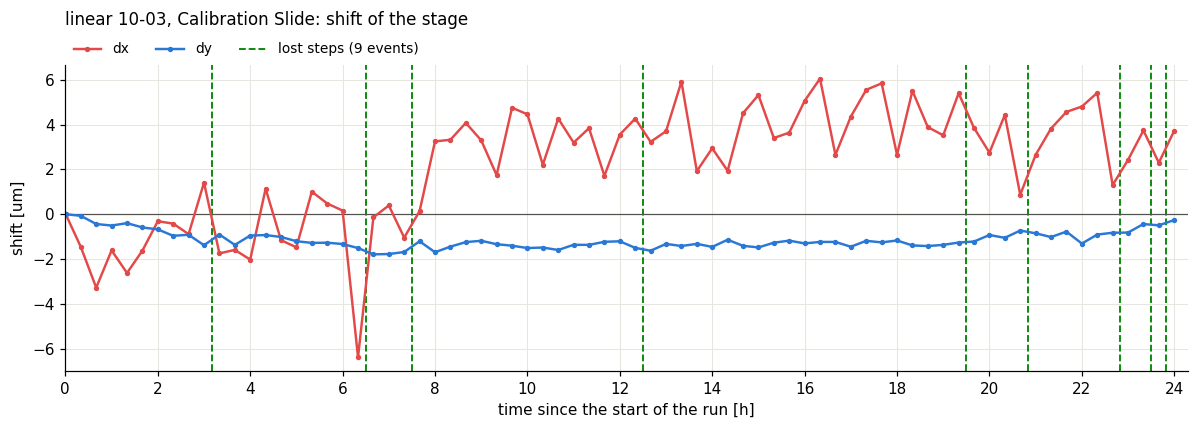

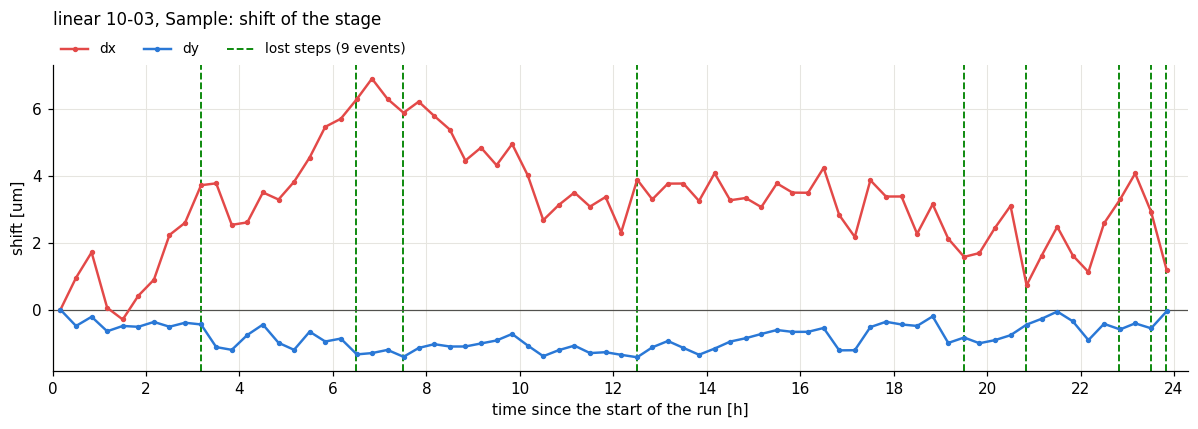

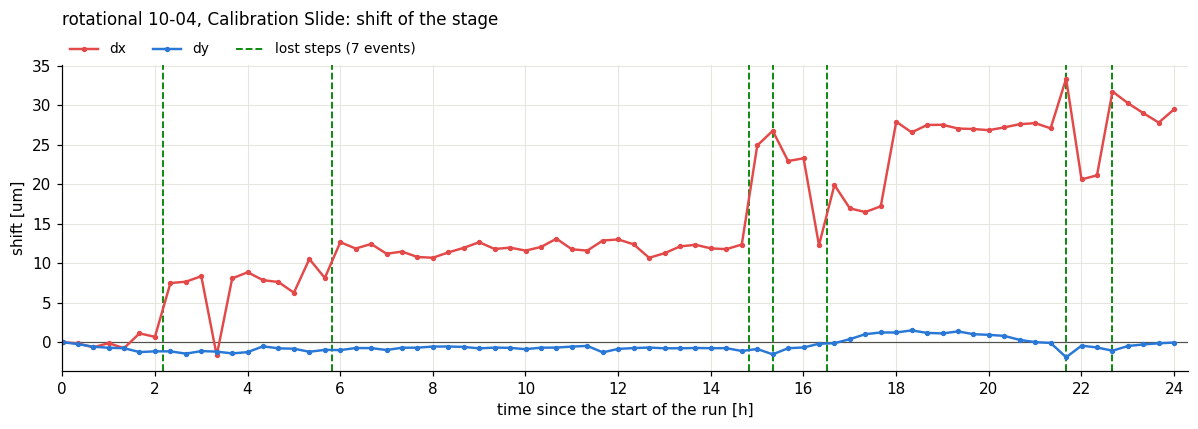

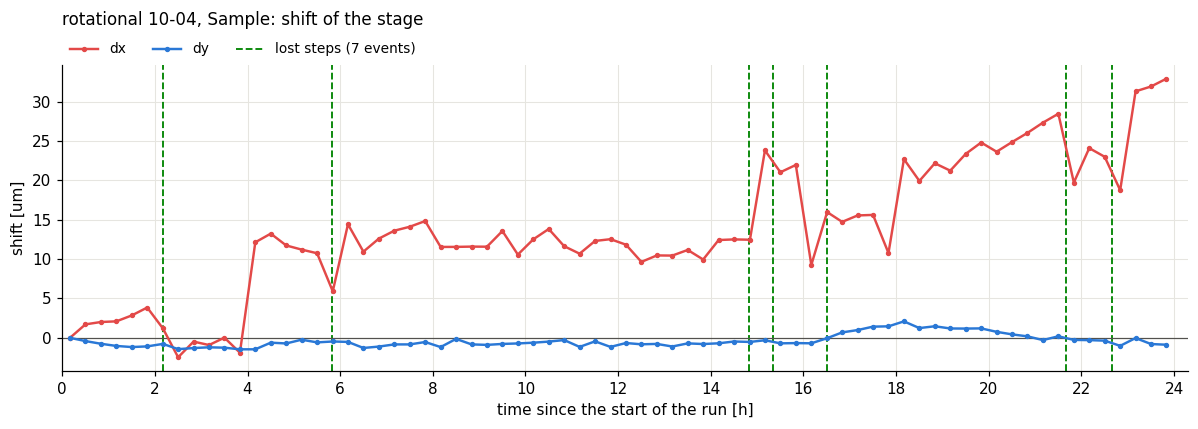

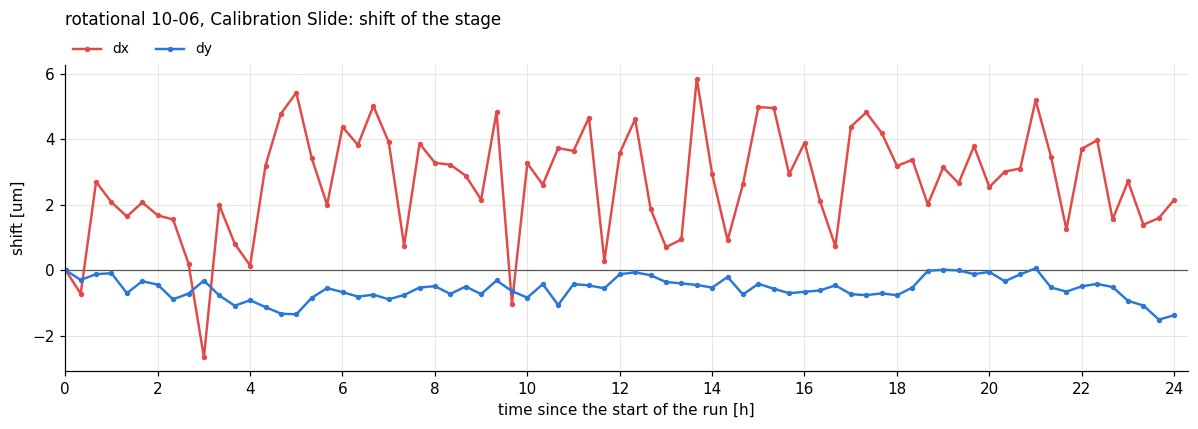

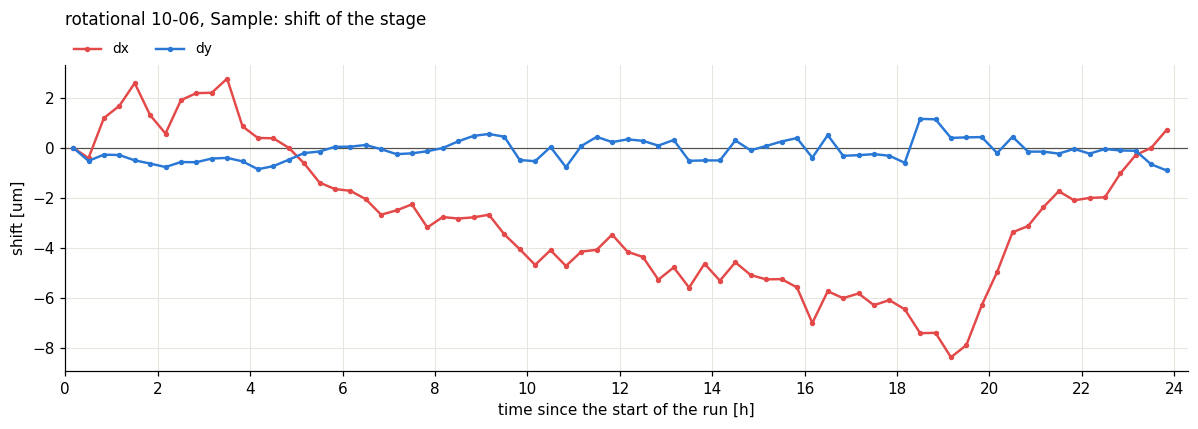

In [3]:
for name, run in runs.items():
    for place in PLACES:
        p = run[place]
        fig, ax = new_plot(f"{name}, {PLACE_NAME[place]}: shift of the stage", "shift [um]")
        ax.plot(p["hours"], p["dx"], ".-", color=COLOR["dx"], label="dx")
        ax.plot(p["hours"], p["dy"], ".-", color=COLOR["dy"], label="dy")
        mark_lost(ax, run)
        finish(fig, ax, f"1_shift_{name}_{place}")

## 2. dx of the three runs, with the compensation zones

The compensation only corrects X when the encoder is more than `comp_counts` off:
5 counts of the linear encoder (10-03) and 39 counts of the rotational one (10-04) are
both 9.75 um; on 10-06 it was 5 counts of the rotational encoder = 1.25 um. The zones
are drawn around the first photo, like `dx`. The y axis is the same in both plots.

On 10-06 `dx` stays within -8.4 .. +2.8 um at the sample and -2.7 .. +5.9 um at the
scale: about as in the run with the linear encoder (-0.3 .. +6.9 and -6.4 .. +6.1 um)
and without the walk-off of 10-04 (up to +33 um). The picture does leave the
+-1.25 um zone of 10-06, but X was never corrected in that run: the encoder itself
did not leave the zone (see 4.1).

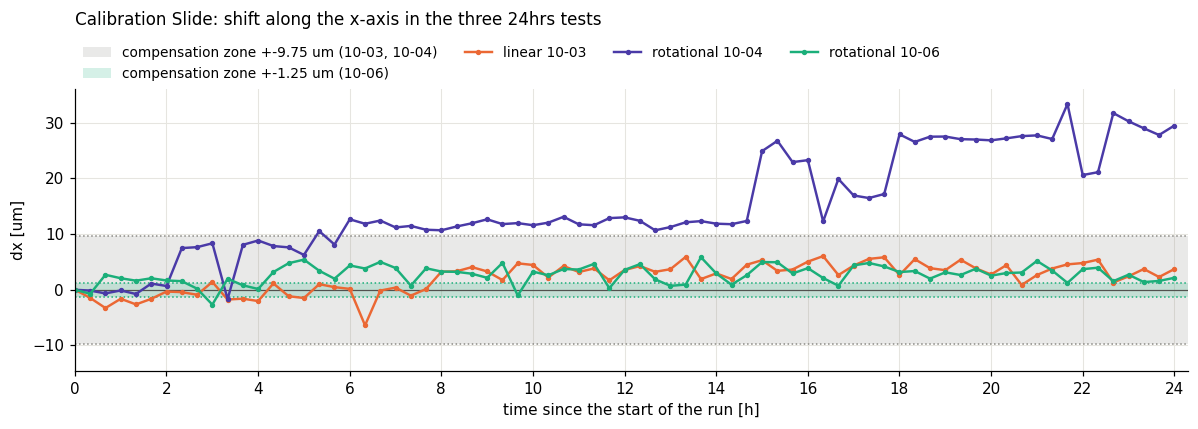

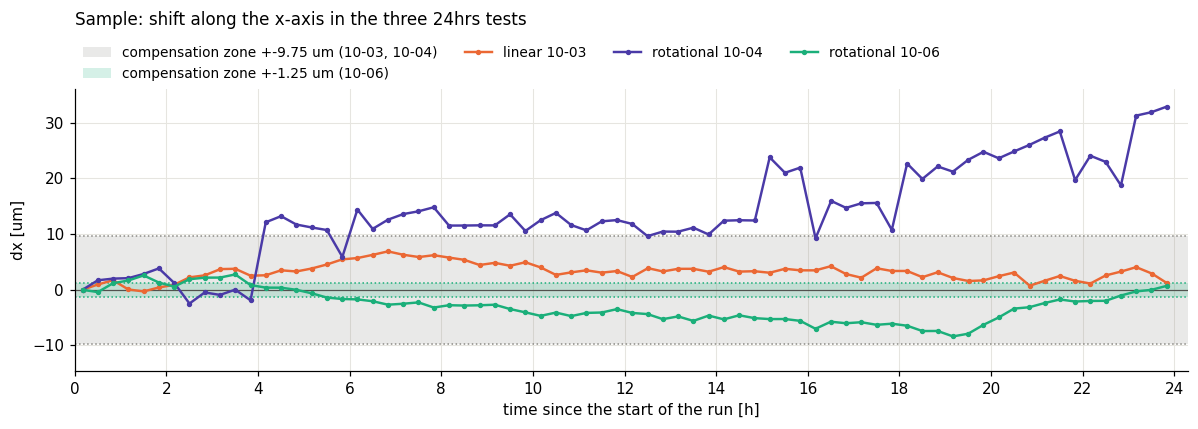

In [14]:
top = 1.08 * max(np.abs(run[place]["dx"]).max() for run in runs.values() for place in PLACES)
zone = max(run["comp_um"] for run in runs.values())

for place in PLACES:
    fig, ax = new_plot(f"{PLACE_NAME[place]}: shift along the x-axis in the three 24hrs tests", "dx [um]")
    mark_zones(ax)
    for name, run in runs.items():
        ax.plot(run[place]["hours"], run[place]["dx"], ".-", color=COLOR[name], label=name)
    ax.set_ylim(-1.5 * zone, top)
    finish(fig, ax, f"2_dx_{place}")

## 3. Encoder minus photo: did the encoder see the shift?

`enc - dx`: the raw count against the first photo, times um per count (1.95 um
linear, 0.25 um rotational), minus the shift of the photo. 0 = the encoder reports
exactly what the photo shows; a value that stays away from 0 is a shift of the
picture the encoder does not know about.

The cell below checks the um per count with the photos, as in `encoder_test.ipynb`:
the change of `dx` from one photo to the next against the change of the count. On
10-06 there is nothing to fit: the count is the same at every photo of a place, so
`enc` is 0 and `enc - dx` is just `-dx`. Everything the photos show in that run is a
shift the rotational encoder did not see.

In [5]:
for name, run in runs.items():
    counts = np.concatenate([np.diff(run[p]["enc"]) / run["um_per_count"] for p in PLACES])
    ddx = np.concatenate([np.diff(run[p]["dx"]) for p in PLACES])
    if not counts.any():
        print(f"{name:<17} the count is the same at every photo of a place: nothing to fit, "
              f"dx moves {np.sqrt((ddx ** 2).mean()):.2f} um rms from photo to photo")
        continue
    print(f"{name:<17} count changes up to {np.abs(counts).max():.0f}: dx moves "
          f"{(counts * ddx).sum() / (counts ** 2).sum():+.2f} um per count "
          f"(r = {np.corrcoef(counts[counts != 0], ddx[counts != 0])[0, 1]:+.2f}, "
          f"used: {run['um_per_count']:+.2f})")

linear 10-03      count changes up to 4: dx moves +0.96 um per count (r = +0.86, used: +1.95)
rotational 10-04  count changes up to 44: dx moves -0.27 um per count (r = -0.89, used: -0.25)
rotational 10-06  the count is the same at every photo of a place: nothing to fit, dx moves 1.54 um rms from photo to photo


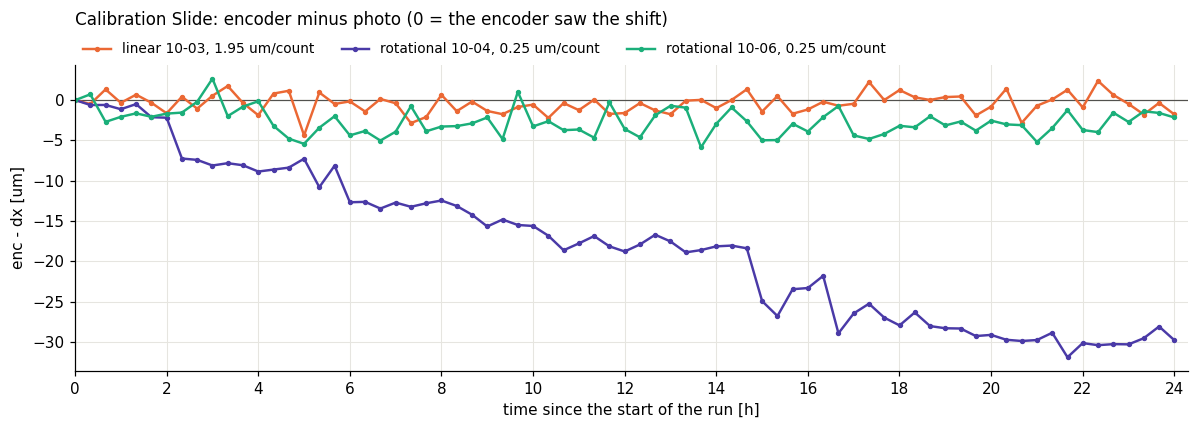

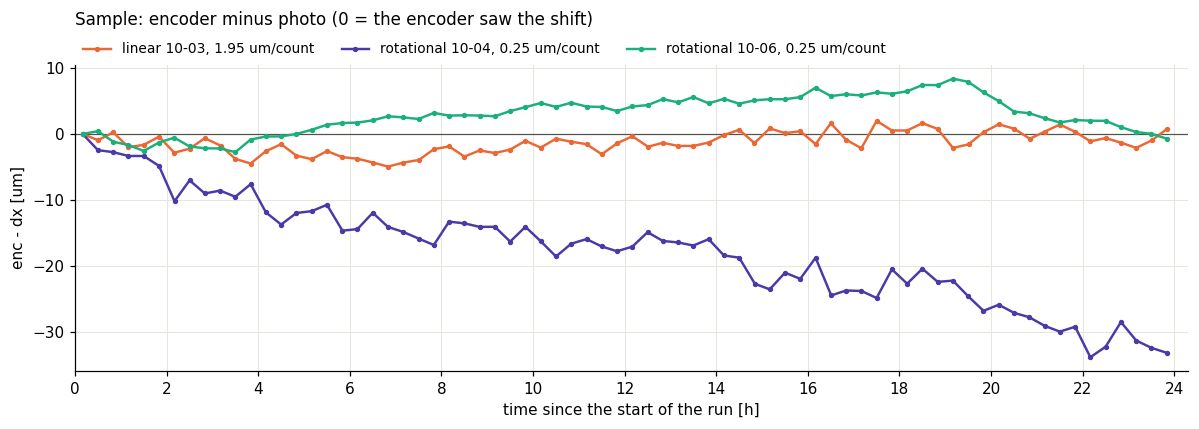

In [ ]:
for place in PLACES:
    fig, ax = new_plot(f"{PLACE_NAME[place]}: encoder minus shift (0 = the encoder saw the shift)",
                       "enc - dx [um]")
    for name, run in runs.items():
        p = run[place]
        ax.plot(p["hours"], p["enc"] - p["dx"], ".-", color=COLOR[name],
                label=f"{name}, {abs(run['um_per_count']):g} um/count")
    finish(fig, ax, f"3_encoder_minus_photo_{place}")

## 4. More

### 4.1 What the compensation saw

The encoder on arrival, before any correction, against the first arrival at the place
(`encDriftCounts` of the run, in um). This is the number the test compares with the
zone; the circles are the visits where it was outside and X was corrected. The visits
with lost steps are left out (thousands of counts off, they are the green lines of
part 1).

10-06 is a flat line at 0: at all 144 arrivals the count is exactly the count of the
first arrival (0 at the scale, 370087 at the sample). On 10-04 the same encoder was up
to 46 counts off on arrival and X was corrected at 16 visits.

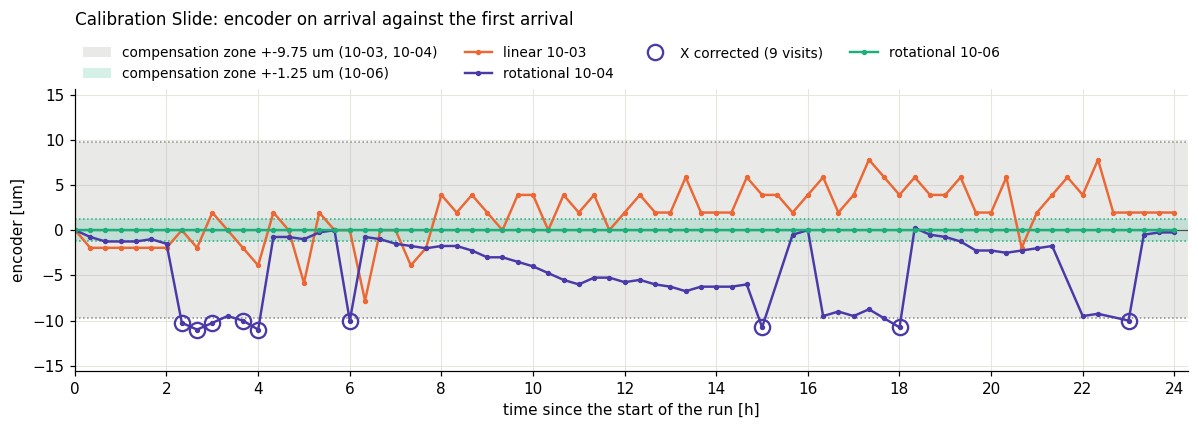

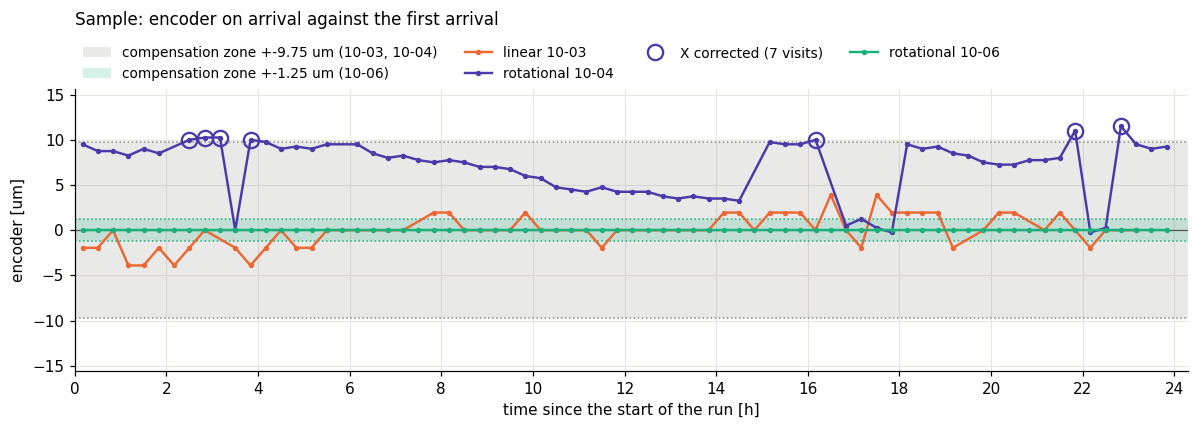

In [7]:
for place in PLACES:
    fig, ax = new_plot(f"{PLACE_NAME[place]}: encoder on arrival against the first arrival",
                       "encoder [um]")
    mark_zones(ax)
    for name, run in runs.items():
        p = run[place]
        keep, comp = ~p["event"], p["comp"]
        ax.plot(p["hours"][keep], p["drift"][keep], ".-", color=COLOR[name], label=name)
        if comp.any():
            ax.plot(p["hours"][comp], p["drift"][comp], "o", mfc="none", mec=COLOR[name], ms=10,
                    mew=1.5, label=f"X corrected ({comp.sum()} visits)")
    ax.set_ylim(-1.6 * zone, 1.6 * zone)
    finish(fig, ax, f"4_compensation_{place}")

### 4.2 Where does the unseen shift come from?

`enc - dx` of part 3 again, one plot per run, with the lost-step events. A step
at a green line = the recovery left the stage at another place than the encoder
thinks; a slope between the lines = slow drift (temperature) the encoder cannot see.
The run of 10-06 has no green line: only the slow part and the scatter from photo to
photo are left.

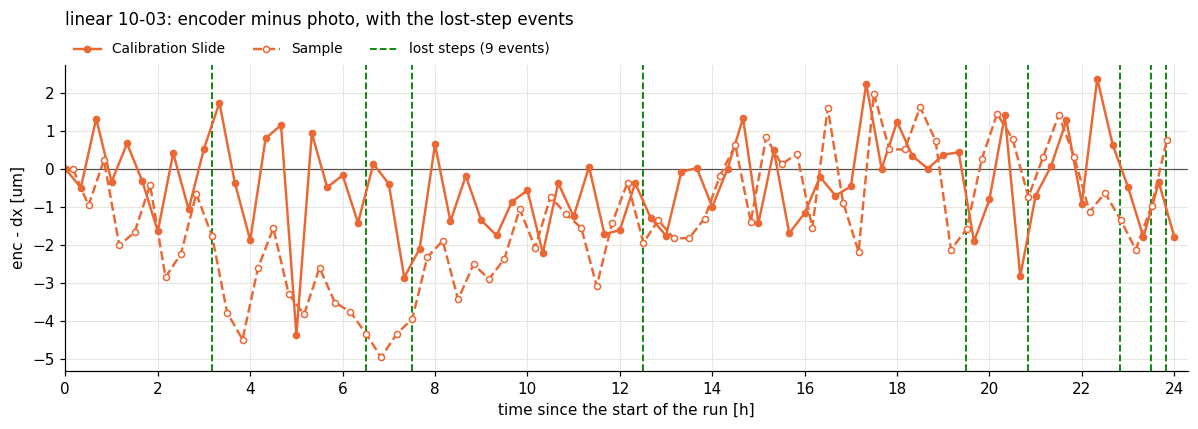

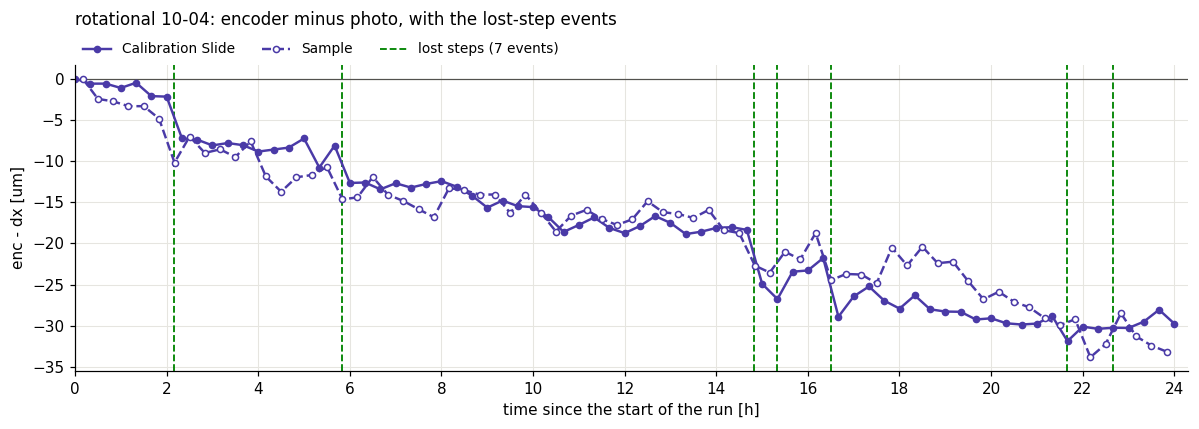

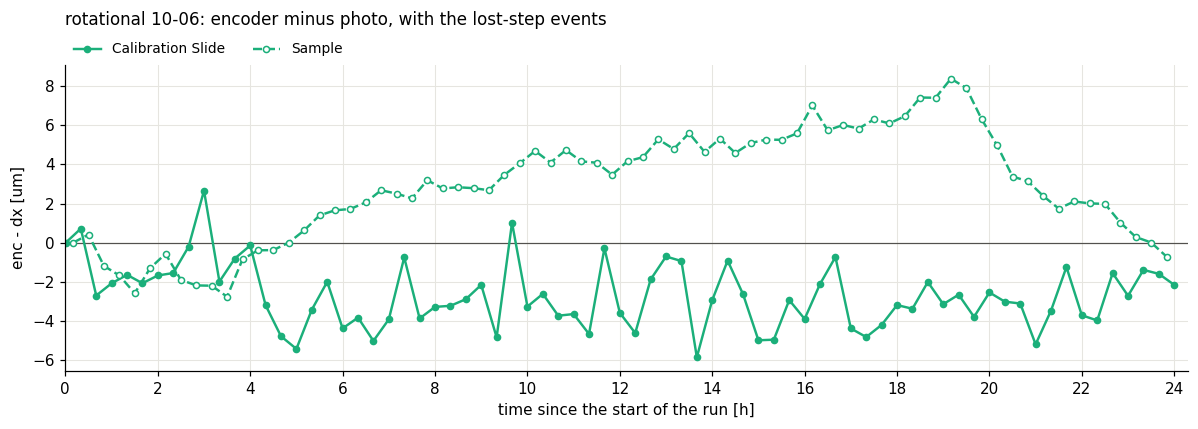

In [8]:
for name, run in runs.items():
    fig, ax = new_plot(f"{name}: encoder minus photo, with the lost-step events", "enc - dx [um]")
    for place, style in zip(PLACES, (dict(ls="-"), dict(ls="--", mfc="white"))):
        p = run[place]
        ax.plot(p["hours"], p["enc"] - p["dx"], "o", color=COLOR[name], ms=4,
                label=PLACE_NAME[place], **style)
    mark_lost(ax, run)
    finish(fig, ax, f"4_unseen_shift_{name}")

### 4.3 Numbers

`dx step` = rms change of `dx` from one photo of a place to the next.
`at lost` = rms change of `enc - dx` between two photos of a place with a lost-step
event of the run in between, `else` = the same for all other pairs of photos.
`lost` = events on the way to this place, `corr.` = visits where X was corrected
because the encoder was out of the zone.

In [9]:
def rms(v):
    return f"{np.sqrt((v ** 2).mean()):.2f}" if v.size else "-"


print(f"{'[um]':<24} {'dx min':>7} {'dx max':>7} {'dx end':>7} {'dx step':>7} {'dy min':>7} {'dy max':>7}   "
      f"{'enc - dx: rms':>13} {'end':>7} {'at lost':>8} {'else':>6}   {'lost':>4} {'corr.':>5}")
for name, run in runs.items():
    t = np.array([e["hours"] for e in run["lost"]])
    for place in PLACES:
        p = run[place]
        unseen = p["enc"] - p["dx"]
        step = np.diff(unseen)
        across = np.array([((t > a) & (t <= b)).any() for a, b in zip(p["hours"], p["hours"][1:])])
        print(f"{name:<16} {place:<7} {p['dx'].min():>7.2f} {p['dx'].max():>7.2f} {p['dx'][-1]:>7.2f} "
              f"{rms(np.diff(p['dx'])):>7} {p['dy'].min():>7.2f} {p['dy'].max():>7.2f}   "
              f"{rms(unseen):>13} {unseen[-1]:>7.2f} "
              f"{rms(step[across]):>8} {rms(step[~across]):>6}   "
              f"{sum(e['place'] == place for e in run['lost']):>4} {p['comp'].sum():>5}")

[um]                      dx min  dx max  dx end dx step  dy min  dy max   enc - dx: rms     end  at lost   else   lost corr.
linear 10-03     scale     -6.39    6.05    3.73    2.06   -1.79    0.00            1.30   -1.78     1.52   1.85      0     0
linear 10-03     sample    -0.29    6.90    1.19    0.85   -1.42    0.00            2.12    0.76     1.14   1.43      9     0
rotational 10-04 scale     -1.68   33.38   29.51    3.94   -1.91    1.50           20.22  -29.76     4.67   1.16      3     9
rotational 10-04 sample    -2.47   32.91   32.91    4.13   -1.46    2.09           19.46  -33.16     4.02   1.83      4     7
rotational 10-06 scale     -2.66    5.85    2.15    2.04   -1.51    0.06            3.16   -2.15        -   2.04      0     0
rotational 10-06 sample    -8.37    2.76    0.71    0.74   -0.91    1.15            4.02   -0.71        -   0.74      0     0


## 5. Lost steps: how often, and where the stage stopped

The table counts the moves at full speed (the first leg to each place is driven
slowly) and the lost-step events among them. `stopped at` = where the stage stood when
the move was over (`stallRawCounts` of the run), as the distance from the scale lines.
`move` = median duration of a full-speed move (`xMoveSec`). `counts on arrival` = the
encoder against the first arrival at the place, over all visits without lost steps.

- 10-06 has no lost steps in 144 moves, the two runs before lost steps in 9 and in 7
  of 144. At the rate of those two runs (16 in 288) the chance of 144 moves in a row
  without one is about 0.03 %, so this is not luck.
- On the way to the sample the stage stopped between 53 and 73 mm from the scale
  lines in both earlier runs, never in the first half of the travel.
- On the way to the scale lines it stopped only on 10-04, 1.4 .. 6.0 mm before the
  target. That is the run with the shorter move: 4.6 s instead of 5.6 s for the same
  travel at the same speed, so with shorter ramps.
- The count on arrival does not scatter any more on 10-06 (10-04: up to 46 counts).

What the data cannot tell is why the stage does not stop any more. Between 10-04 and
10-06 the encoder pins were changed (and the slave flashed again), and both places
were taught again: against the reference photo of 10-03 the scale lines were 59 um
off in y at the first try of 10-06 (correlation 0.63; on 10-04: 4 um, 0.96), so the
slide or the stage was moved in between.

In [10]:
def span(v, fmt="{:.0f}"):
    return f"{fmt.format(min(v))} .. {fmt.format(max(v))}" if len(v) else "-"


print(f"{'':<17} {'':>11} {'fast':>5}  {'to the sample':>20}  {'to the scale lines':>20} "
      f"{'lost steps':>16} {'move':>6} {'counts on':>10}")
print(f"{'':<17} {'started':>11} {'moves':>5}  {'lost':>4} {'stopped at [mm]':>15}  {'lost':>4} "
      f"{'stopped at [mm]':>15} {'per event':>16} {'[s]':>6} {'arrival':>10}")
for name, run in runs.items():
    lost = run["lost"]
    at = {place: [e["mm"] for e in lost if e["place"] == place] for place in PLACES}
    # the encoder on arrival of all visits without lost steps, in counts
    counts = np.concatenate([run[p]["drift"][~run[p]["event"]] for p in PLACES]) / run["um_per_count"]
    print(f"{name:<17} {run['started']:>11} {run['moves']:>5}  "
          f"{len(at['sample']):>4} {span(at['sample'], '{:.1f}'):>15}  "
          f"{len(at['scale']):>4} {span(at['scale'], '{:.1f}'):>15} "
          f"{span([e['steps'] for e in lost]):>16} {np.median(run['move_sec']):>6.1f} "
          f"{span(counts, '{:+.0f}'):>10}")

                               fast         to the sample    to the scale lines       lost steps   move  counts on
                      started moves  lost stopped at [mm]  lost stopped at [mm]        per event    [s]    arrival
linear 10-03      10-03 11:04   144     9    53.1 .. 73.2     0               -  61526 .. 125874    5.6   -4 .. +4
rotational 10-04  10-04 15:15   144     4    57.0 .. 73.4     3      1.4 .. 6.0   4490 .. 113726    4.6 -46 .. +44
rotational 10-06  10-06 13:54   144     0               -     0               -                -    5.6   +0 .. +0


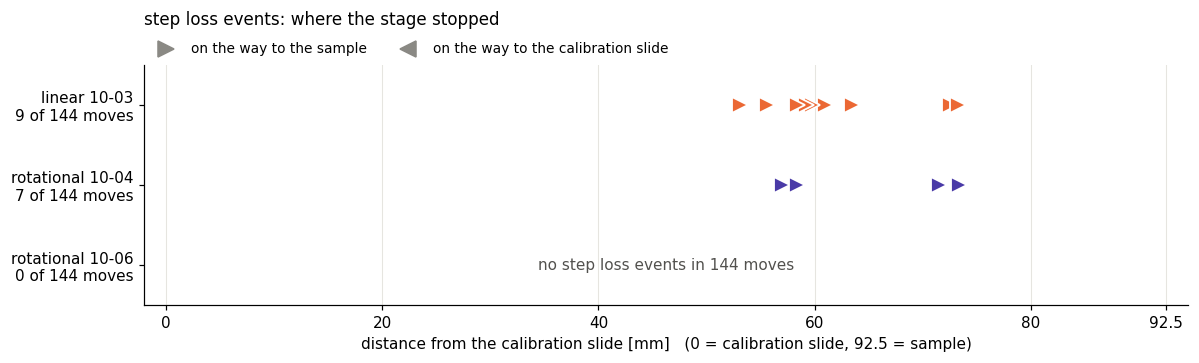

In [13]:
travel = max(run["travel_mm"] for run in runs.values())
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.set_title("step loss events: where the stage stopped")
for row, (name, run) in enumerate(runs.items()):
    for place, marker in (("sample", ">"), ("calibration slide", "<")):
        at = [e["mm"] for e in run["lost"] if e["place"] == place]
        ax.plot(at, [row] * len(at), marker, color=COLOR[name], ms=10, mec="white", mew=1.2, ls="none")
    if not run["lost"]:
        ax.text(travel / 2, row, f"no step loss events in {run['moves']} moves", ha="center", va="center",
                color=COLOR["ink"], fontsize=10)
for place, marker in (("sample", ">"), ("calibration slide", "<")):
    ax.plot([], [], marker, color=COLOR["zone"], ms=10, ls="none",
            label=f"on the way to the {'sample' if place == 'sample' else 'calibration slide'}")
ax.set_yticks(range(len(runs)), [f"{name}\n{len(run['lost'])} of {run['moves']} moves"
                                 for name, run in runs.items()])
ax.set_ylim(len(runs) - 0.5, -0.5)
ax.set_xlim(-2, travel + 2)
ax.set_xticks([0, 20, 40, 60, 80, travel], ["0", "20", "40", "60", "80", f"{travel:.1f}"])
ax.set_xlabel(f"distance from the calibration slide [mm]   (0 = calibration slide, {travel:.1f} = sample)")
ax.grid(axis="y", visible=False)
finish(fig, ax, "5_lost_steps_where")